# Load the data

In [1]:
import pandas as pd
import re

In [2]:
ace_reviews = pd.read_csv("ace_reviews_April_2026.csv")
ace_reviews_copy = ace_reviews.copy()
ace_reviews_copy

,review_id,reviews
0,Arif Supriyanto,Cukup berkesan dan membantu
1,Fertika Indri Dhamaningrum,Good
2,tiffani bunga,really good 👍
3,Dara ya,rekomended study english
4,lulu1 rofi,so fun and have interactive methode for learn
...,...,...
99,Fatma yovita Amri,Best place to upgrade your english 👍🏻👍🏻
100,Muhamad Kresna Maulidani,Tempat yang bagus
101,Ayu Khoerunisa,My experience studying at ACE English Kebumen ...
102,Tuty HT,"experienced and fun teachers, easy to understa..."


# Cleaning

In [3]:
def clean_text(text):
    # 1. Lowercase
    text = str(text)            #change into strings
    text = text.lower()         #turns all captial letters into small
    
    # 2. Remove emoji (simple version)
    text = re.sub(r'[^\w\s-]', '', text)
    
    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 4. Fix repeated characters (e.g. "bestttt" → "best")
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    
    # 5. Normalize repeated words → "baik baik" → "baik-baik"
    text = re.sub(r'\b(\w+)\s+\1\b', r'\1-\1', text)

    # 6. remove "nya" suffix
    text = re.sub(r'\b(\w+)nya\b', r'\1', text)
    
    # 7. Remove extra spaces
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    
    return text

In [4]:
ace_clean_reviews = ace_reviews_copy['reviews'].apply(clean_text)
ace_clean_reviews

0                            cukup berkesan dan membantu
1                                                   good
2                                            really good
3                               rekomended study english
4          so fun and have interactive methode for learn
                             ...                        
99                    best place to upgrade your english
100                                    tempat yang bagus
101    my experience studying at ace english kebumen ...
102    experienced and fun teachers easy to understan...
103        fun english method good tutor get new friends
Name: reviews, Length: 104, dtype: object

# Tokenize

In [5]:
all_words = " ".join(ace_clean_reviews).split()
print(all_words)

['cukup', 'berkesan', 'dan', 'membantu', 'good', 'really', 'good', 'rekomended', 'study', 'english', 'so', 'fun', 'and', 'have', 'interactive', 'methode', 'for', 'learn', 'so', 'cool', 'sukses', 'selalu', 'ace', 'english', 'kebumen', 'happy', 'to', 'be', 'able', 'to', 'study', 'here', 'meet', 'fun', 'teachers', 'and', 'friends', 'so', 'fun', 'good', 'amazing', 'happy', 'super', 'fun', 'good', 'the', 'best', 'guru', 'nya', 'ramahh', 'baik', 'kalau', 'ngejelasin', 'juga', 'okee', 'bgtkalau', 'mau', 'course', 'english', 'disini', 'aja', 'ges', 'jangan', 'ragu', 'cara', 'ngajar', 'friendly', 'banget', 'jadi', 'cepet', 'banget', 'paham', 'sukses', 'selalu', 'ace', 'english', 'menyenangkan', 'menyenangkan', 'bangetutornyaa', 'baik', 'bangetnyaman', 'banget', 'disini', 'tutor', 'nya', 'cantik', 'dan', 'ganteng', 'banget', 'terus', 'kalo', 'belajar', 'disana', 'seru', 'maju', 'terus', 'ace', 'english', 'asik', 'banget', 'joinn', 'kuy', 'tempat', 'nyaman', 'guru', 'baik', 'ramah', 'semua', 'pem

# Counting

## Intial count word (unfiltered)

In [6]:
from collections import Counter

word_counts = Counter(all_words)

data1 = []
for word, count in word_counts.most_common():
    data1.append([word,count])

result =  pd.DataFrame(data1, columns = ["word","count"])
result

,word,count
0,dan,33
1,english,28
2,tutor,28
3,yang,25
4,to,23
...,...,...
455,your,1
456,people,1
457,sharing,1
458,experienced,1


## Creating the stopword / filter

In [7]:
excluded_word = ["to","the","and","so", "is","in","also","for","di","ace","i","juga","nya","yg","jadi","untuk","dan","yang","disini"]#"sangat","banget"]

## Counting the filtered word and the metrics

In [8]:
total_reviewers = len(ace_reviews_copy["review_id"])
print("Total reviewers : ",total_reviewers)
total_words = sum(word_counts.values())
print("Total used word : ",total_words)

data2 = []
for word,count in word_counts.most_common():
    if word not in excluded_word:
        density = (count/total_reviewers)*100
        percentage = (count/total_words)*100
        data2.append([word,count,percentage,density])

filtered_result =  pd.DataFrame(data2, columns = ["word","count","percentage","density"])
filtered_result["percentage"] = filtered_result["percentage"].round(2)
filtered_result["density"] = filtered_result["density"].round(2)
filtered_result

Total reviewers :  104
Total used word :  1274


,word,count,percentage,density
0,english,28,2.20,26.92
1,tutor,28,2.20,26.92
2,tempat,23,1.81,22.12
3,inggris,22,1.73,21.15
4,bahasa,21,1.65,20.19
...,...,...,...,...
436,your,1,0.08,0.96
437,people,1,0.08,0.96
438,sharing,1,0.08,0.96
439,experienced,1,0.08,0.96


# Visualize

In [9]:
top_n = 16
top_data = filtered_result.head(top_n)
top_data

,word,count,percentage,density
0,english,28,2.20,26.92
1,tutor,28,2.20,26.92
2,tempat,23,1.81,22.12
3,inggris,22,1.73,21.15
4,bahasa,21,1.65,20.19
5,belajar,19,1.49,18.27
6,sangat,18,1.41,17.31
7,ramah,16,1.26,15.38
8,banget,15,1.18,14.42
9,good,14,1.10,13.46


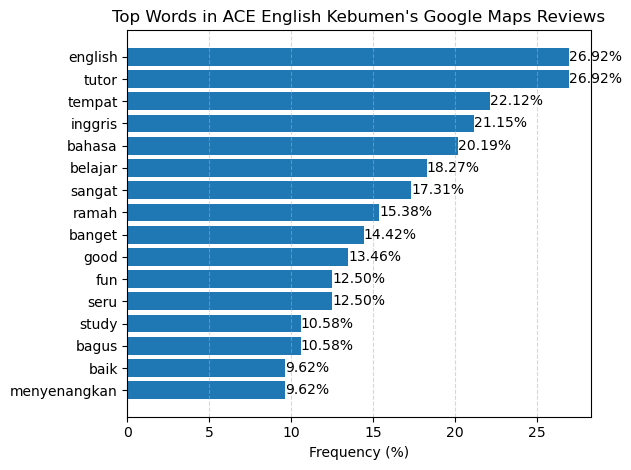

In [10]:
import matplotlib.pyplot as plt

word = top_data["word"]
value = top_data["density"]

plt.barh(word,value)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
# Add value labels
for i, v in enumerate(value):
    plt.text(v, i, f"{v:.2f}%", va='center')

plt.title("Top Words in ACE English Kebumen's Google Maps Reviews")
#plt.ylabel("Word :")
plt.xlabel("Frequency (%)")

plt.tight_layout()
plt.show()